<div style="background-color:#1a1a2e;padding:35px;border-radius:16px;margin-bottom:20px;text-align:center;">
<h1 style="color:#e94560;font-size:2.4em;margin-bottom:8px;">📊 Digital Marketing Campaign Analysis</h1>
<h3 style="color:#a8dadc;font-weight:400;">End-to-End Data Science Project</h3>
<p style="color:#aaa;margin-top:10px;text-align:center;">EDA · Feature Engineering · Preprocessing · Modeling · Evaluation · Business Insights</p>
<h3 style="color:#aaa;margin-top:10px;text-align:center;"> Created by: Pooja Chavan, Data Analyst</h3>
</div>

In [1]:
# importing Librabries
import numpy as np
import pandas as pd
import math
import warnings
warnings.filterwarnings('ignore')

# Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
plt.rcParams['figure.dpi']=120
PALETTE = ['#e94560', '#0f3460', '#533483', '#06d6a0', '#ffd166']

#preprocessing libraries
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

#modelling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

#Imbalanced Data
from imblearn.over_sampling import SMOTE

# Evaluation Metrics
from sklearn.metrics import (confusion_matrix, classification_report, 
                            roc_auc_score, roc_curve, precision_recall_curve,
                            average_precision_score, f1_score)
# Explainability
import shap

# Exporting 
import pickle

print("All Libraries are imported successfully")

All Libraries are imported successfully


<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
<h3><b>📢 Problem Statement </b></h3>

The objective of this project is to analyze digital marketing campaign performance and identify the key factors influencing customer conversion. The dataset includes customer demographics, campaign details, engagement metrics, and website interaction data.

The goal is to:

- Evaluate the effectiveness of different marketing channels and campaign types
- Understand customer behavior across the conversion funnel
- Identify high-value customer segments
- Analyze the impact of advertising spend on conversion outcomes
- Build a predictive model to determine the likelihood of customer conversion

This analysis aims to provide data-driven insights that help optimize marketing strategies, improve customer targeting, and maximize return on investment (ROI).

### Data Gathering 

In [3]:
digital_data = pd.read_csv(r'digital_marketing_campaign_dataset.csv')
digital_data.sample(10)

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
3998,11998,29,Male,62399,PPC,Conversion,3070.911881,0.118116,0.192864,2,8.073096,6.005458,54,17,2,9,2857,IsConfid,ToolConfid,1
6228,14228,43,Female,26172,Referral,Retention,9534.734480,0.200697,0.143655,11,8.678442,1.842271,81,1,3,5,1209,IsConfid,ToolConfid,1
3186,11186,30,Female,90624,PPC,Retention,3844.370247,0.251832,0.163869,27,6.859417,2.803954,91,19,7,0,495,IsConfid,ToolConfid,1
711,8711,44,Female,138181,Social Media,Consideration,2666.681210,0.171224,0.168733,31,7.696038,14.849803,64,11,5,0,4218,IsConfid,ToolConfid,1
3797,11797,28,Male,38254,Email,Consideration,610.960612,0.015896,0.162835,8,9.520871,9.420645,72,6,7,1,4225,IsConfid,ToolConfid,1
5981,13981,57,Male,95664,Email,Retention,2369.476196,0.288291,0.102302,26,2.749760,9.244724,82,4,5,1,2088,IsConfid,ToolConfid,1
5431,13431,45,Female,135253,Social Media,Consideration,168.434653,0.176340,0.137679,32,1.898687,8.059893,23,10,2,6,1674,IsConfid,ToolConfid,1
300,8300,49,Female,70998,Email,Awareness,5855.301677,0.100039,0.073715,41,9.349764,12.984770,57,11,0,9,4678,IsConfid,ToolConfid,1
5855,13855,43,Female,64407,Referral,Awareness,7955.497692,0.122874,0.153432,10,9.580143,12.467372,77,17,3,2,4776,IsConfid,ToolConfid,1
7022,15022,40,Female,128938,Social Media,Consideration,2105.968228,0.192791,0.165186,34,8.392588,5.870829,89,9,3,8,956,IsConfid,ToolConfid,1


Column | Description
:-|:-
CustomerID|	Unique identifier assigned to each customer
Age	|Age of the customer
Gender|	Gender of the customer
Income	|Income level indicating purchasing power
CampaignChannel|	Marketing channel used (Email, Social Media, Search Ads, etc.)
CampaignType	|Type of campaign (Awareness, Conversion, Retargeting, etc.)
Advertising Investment|	AdSpend	Amount spent on advertising for the campaign/customer
ClickThroughRate (CTR)|	Percentage of users who clicked on the advertisement
ConversionRate	|Percentage of users who completed the desired action after clicking
SocialShares	|Number of times content was shared on social platforms
EmailOpens|	Number of marketing emails opened
EmailClicks	|Number of clicks generated from emails
WebsiteVisits|	Total number of website visits by the user
PagesPerVisit|	Average number of pages viewed per visit
TimeOnSite|	Average time spent on the website
PreviousPurchases|	Number of past purchases made by the customer
LoyaltyPoints|	Reward/loyalty points accumulated
Advertising Platform|	AdvertisingPlatform	Platform used for ads (iscanfid or not)
AdvertisingTool|	Tool/software used to manage campaigns
Target Variable	Conversion|	Indicates whether customer converted (1 = Yes, 0 = No)

<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
<h3>👨‍💼<b><u>  Business Questions</u></b></h3>
<ol>
<li>Which marketing channel delivers the highest conversion rate and ROI? </li></li>
<li>How does advertising spend (AdSpend) impact conversion outcomes? </li>
<li>Which customer segments (Age, Gender, Income) are most likely to convert? </li>
<li>How does website engagement (TimeOnSite, PagesPerVisit, WebsiteVisits) influence conversion?</li>
<li>Which campaign types (Awareness, Retargeting, Conversion campaigns) are most effective?</li>
<li>How effective are email marketing efforts (EmailOpens, EmailClicks) in driving conversions?</li>
<li>Do returning customers (PreviousPurchases, LoyaltyPoints) convert more than new customers?</li>
</ol>
</div>

## EDA

### Basic Analysis of Data 
- number of rows/columns
- finding missing values
- duplicated values
- description of basic statistics

In [145]:
digital_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

- from this we can tell there is no missing value present in the dataset but anamolies can be present
- There are 8000 rows and 20 columns present in this dataset

In [148]:
digital_data.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">

<h3>📊 Key Insights</h3>

<ul>
<li><b>Customer Engagement:</b> Users are highly active — frequent visits, good time on site, and multiple pages explored.</li>

<li><b>Conversion Concern:</b> The conversion rate (~87%) seems unusually high, suggesting possible data bias or definition issues.</li>

<li><b>Segmentation Opportunity:</b> Wide income variation indicates a need to segment customers for better targeting.</li>

<li><b>Email Performance:</b> High open rates but lower clicks suggest improvement needed in content or call-to-action.</li>

<li><b>Marketing Efficiency:</b> High ad spend without clear ROI makes it difficult to evaluate effectiveness.</li>
</ul>

</div>

### Finding Anamolies

Based on the info() output, we can confirm that the dataset has consistent data types and no missing values in numerical columns.

However, this does not guarantee the absence of anomalies. Further analysis such as summary statistics and distribution checks is required to identify outliers or unusual pattern


For categorical (string) columns, we should examine unique values and frequency distributions to detect inconsistencies, rare categories, or data quality issues.

In [223]:
def find_anamoly():
    cat_col = digital_data.select_dtypes(include='object').columns
    for col in cat_col:
        print(col,':',digital_data[col].unique())
        

In [225]:
find_anamoly()

Gender : ['Female' 'Male']
CampaignChannel : ['Social Media' 'Email' 'PPC' 'Referral' 'SEO']
CampaignType : ['Awareness' 'Retention' 'Conversion' 'Consideration']
AdvertisingPlatform : ['IsConfid']
AdvertisingTool : ['ToolConfid']


<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">

<h3>🧹 Data Quality & Feature Observations</h3>

<ul>
<li><b>Data Consistency:</b> No major anomalies or unexpected values were observed in the dataset based on summary statistics.</li>

<li><b>Low-Variance Features:</b> Columns <b>AdvertisingPlatform</b> and <b>AdvertisingTool</b> contain only a single unique value, making them non-informative for modeling and suitable for removal.</li>

<li><b>Categorical Overview:</b>
    <ul>
        <li><b>Gender:</b> Female, Male</li>
        <li><b>Campaign Channel:</b> Social Media, Email, PPC, Referral, SEO</li>
        <li><b>Campaign Type:</b> Awareness, Retention, Conversion, Consideration</li>
    </ul>
</li>

</ul>

</div>

In [171]:
# finding duplicate values 
digital_data.duplicated().sum()

0

- Data does not have any duplicated info.

In [219]:
#finding data distribution in categorical columns
def data_distribution():
    cat_col = digital_data.select_dtypes(include = 'object').columns
    
    for col in cat_col:
        print(digital_data[col].value_counts())
        print()

In [221]:
data_distribution()

Gender
Female    4839
Male      3161
Name: count, dtype: int64

CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64

AdvertisingPlatform
IsConfid    8000
Name: count, dtype: int64

AdvertisingTool
ToolConfid    8000
Name: count, dtype: int64



<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
    <ul>
        <li>The categorical feature distributions are relatively balanced across most campaign-related variables, with no extreme skew observed.</li>
        <li>However, the Gender distribution shows a moderate imbalance (~60% Female, ~40% Male), which may influence model behavior.</li>
        <li>Additionally, distribution balance alone does not confirm the absence of bias. Further analysis is required to evaluate how these categories relate to the target variable (Conversion) and to identify any potential bias in outcomes.</li>
    </ul>
</div>

## Univeriate Analysis

### Finding Outliers

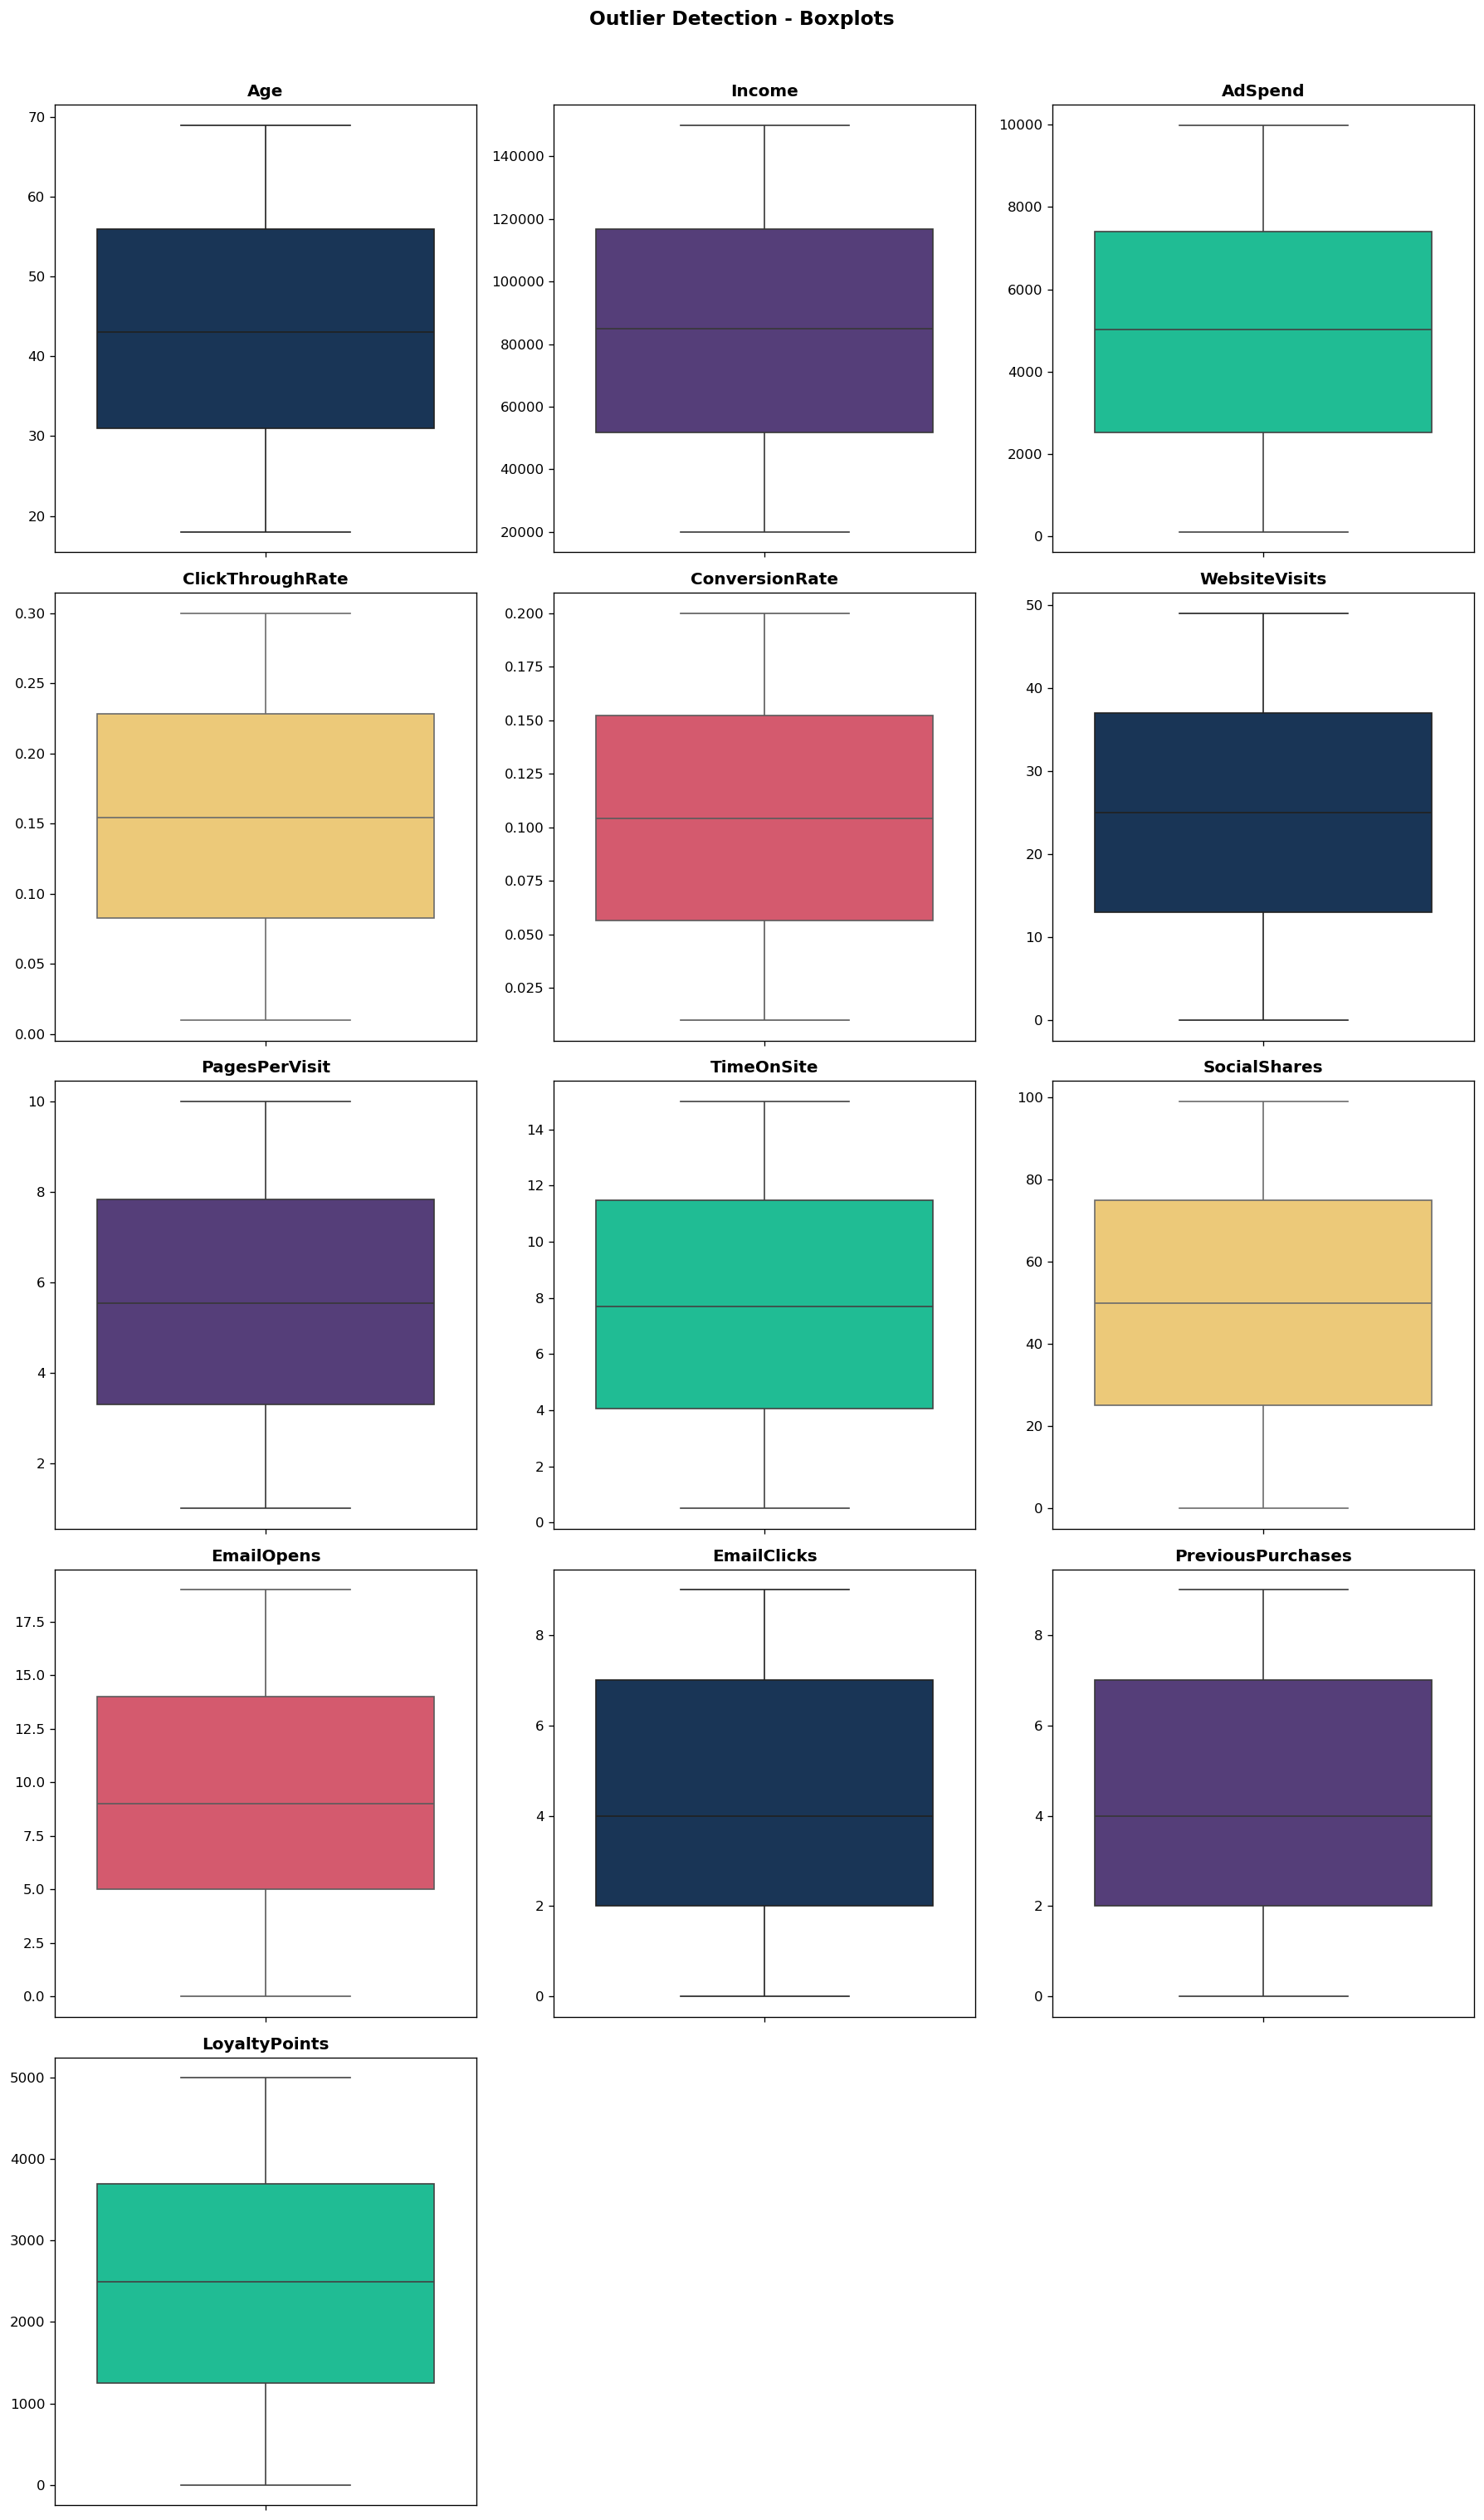

In [32]:

num_col = digital_data.select_dtypes(include=['int64','float64']).columns.drop(['CustomerID','Conversion'])
n = len(num_col)
cols = 3
rows = math.ceil(n/cols)
    
plt.figure(figsize=(15,5*rows))

for i,col in enumerate(num_col,1):
    plt.subplot(rows,cols,i)
    sns.boxplot(digital_data[col],color = PALETTE[i%len(PALETTE)],
               flierprops = dict(marker = 'o', markerfacecolor = 'red', markersize = 3, alpha = 0.5))
    plt.ylabel('')
    plt.title(col, fontsize = 12, fontweight = "bold")

plt.suptitle("Outlier Detection - Boxplots", fontsize = 14, fontweight = "bold", y = 1.01)
plt.tight_layout()
plt.show()

<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
   The boxplot analysis indicates that most numerical features <b>do not exhibit significant outliers</b>, suggesting that the dataset is relatively clean and well-distributed. Variables such as <b>Income, AdSpend, ClickThroughRate, and ConversionRate show a reasonable spread without extreme values</b>, indicating stable campaign and customer behavior patterns. Similarly, website engagement metrics like <b>TimeOnSite, PagesPerVisit, and WebsiteVisits do not display abnormal deviations, reflecting consistent user interaction</b>. Customer-related features such as PreviousPurchases and LoyaltyPoints show natural variation but no extreme anomalies. Overall, the absence of major outliers reduces the need for extensive outlier treatment and supports reliable downstream analysis and modeling.
</div>

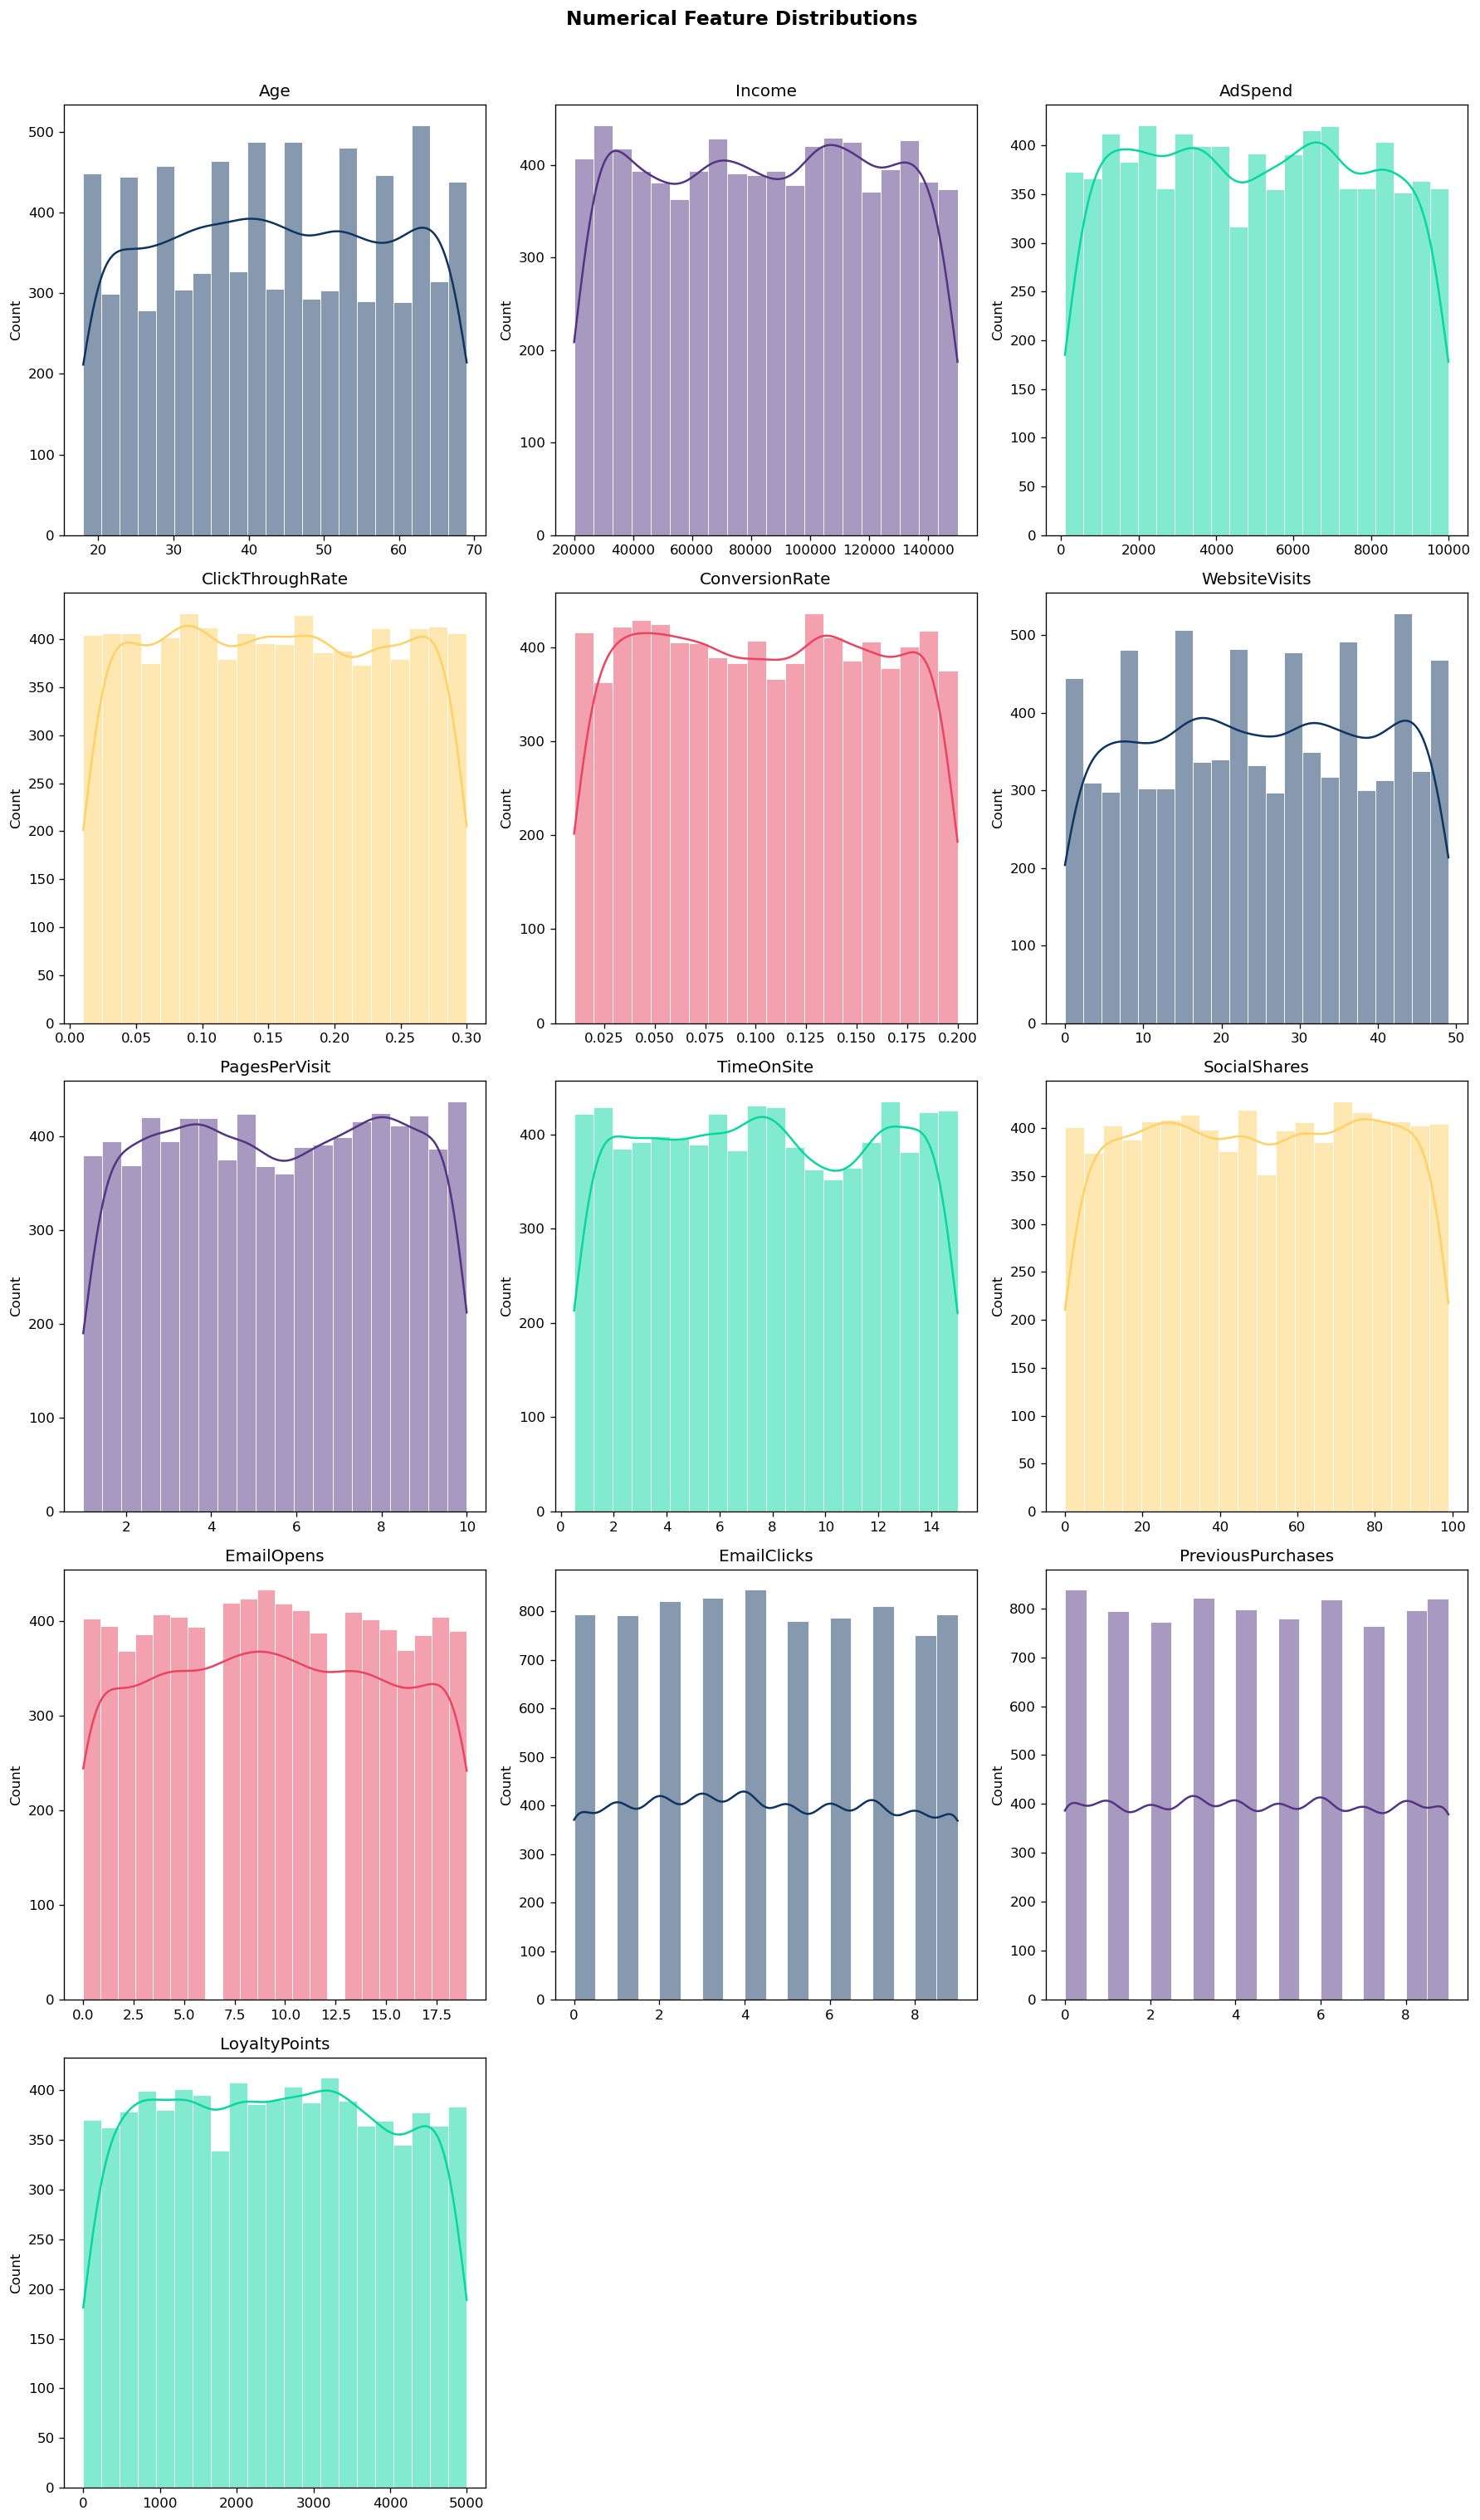

In [34]:
# histplot for distribution of numberical data 

num_col = digital_data.select_dtypes(include=['int64','float64']).columns.drop(['CustomerID','Conversion'])

n = len(num_col)
cols = 3
rows = math.ceil(n/cols)

plt.figure(figsize=(15,5*rows))
for i,col in enumerate(num_col,1):
    plt.subplot(rows,cols,i)
    sns.histplot(digital_data[col],kde=True,
                color = PALETTE[i%len(PALETTE)],
                 edgecolor = 'white', linewidth = 0.5)
    plt.xlabel("")
    plt.title(col)
plt. suptitle("Numerical Feature Distributions", fontsize =14, fontweight = 'bold', y=1.01)
plt.tight_layout()
plt.show()

<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
    Looking at the distributions, most features seem quite <b> evenly spread, which means the data covers a wide variety of customers and behaviors</b>. There isn’t any strong skew or unusual pattern in variables like Age, Income, AdSpend, or engagement metrics, suggesting that no single group dominates the dataset. This is actually a good sign because it allows for fair analysis across different types of users. It also means that we won’t get much insight just by looking at individual variables alone — the real understanding will come from how these features interact with conversion and influence customer decisions.
</div>

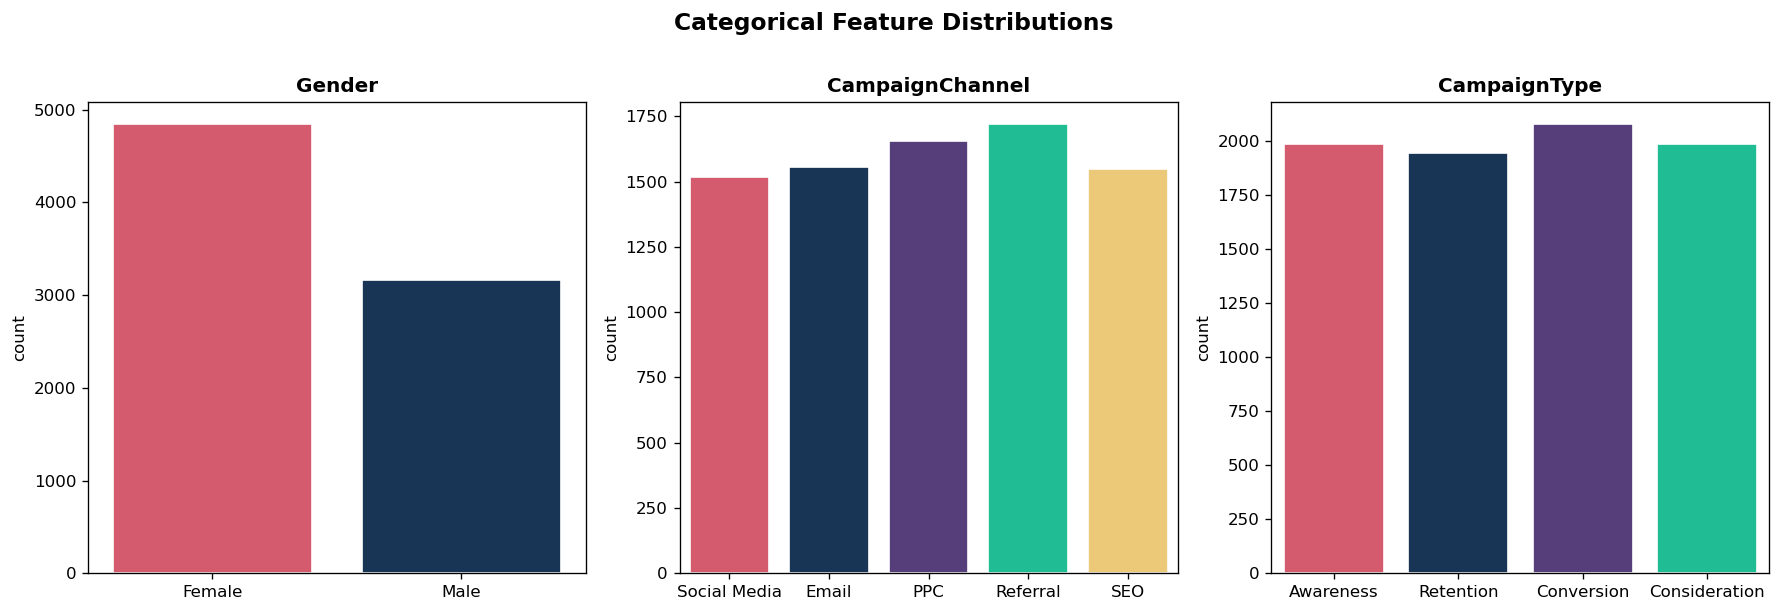

In [40]:
# plotting countplot for categorical columns

cat_col = digital_data.select_dtypes(include='object').columns.drop(['AdvertisingPlatform','AdvertisingTool'])
    
n = len(cat_col)
cols = 3 
rows = math.ceil(n/3)
    
plt.figure(figsize=(15,5*rows))
for i, col in enumerate(cat_col,1):
    plt.subplot(rows,cols,i)
    sns.countplot(x = digital_data[col], palette=PALETTE, edgecolor = 'white')
    plt.xlabel("")
    plt.title(col, fontsize = 12, fontweight = 'bold')

plt.suptitle("Categorical Feature Distributions", fontsize = 14, fontweight = 'bold', y=1.01)
plt.tight_layout()
plt.show()

<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
    From the categorical analysis, <b>Gender shows a slight imbalance</b>, with ,<b>female customers being more represented than male customers</b>. However, other variables like <b>CampaignChannel and CampaignType are quite evenly distributed</b>, indicating that campaigns are being run fairly across different channels and strategies. This balanced distribution is useful because it allows for unbiased comparison of campaign performance, while the gender difference may be worth exploring further to see if it impacts conversion behavior.
</div>

## Bivariate Analysis (vs. Conversion)

#### Conversion By Channel

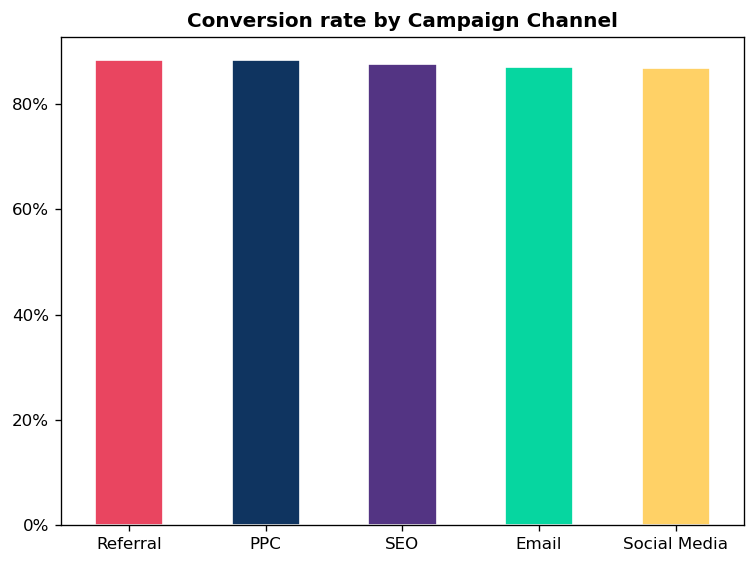

In [72]:
channel_conv = digital_data.groupby('CampaignChannel')['Conversion'].mean().sort_values(ascending = False)
disp = channel_conv.plot(kind = 'bar', color = PALETTE, edgecolor = 'white', rot = 0)
disp.set_title("Conversion rate by Campaign Channel", fontweight = 'bold')
disp.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
disp.set_xlabel("")

plt.tight_layout()
plt.show()

#### Conversion By Campaign Type

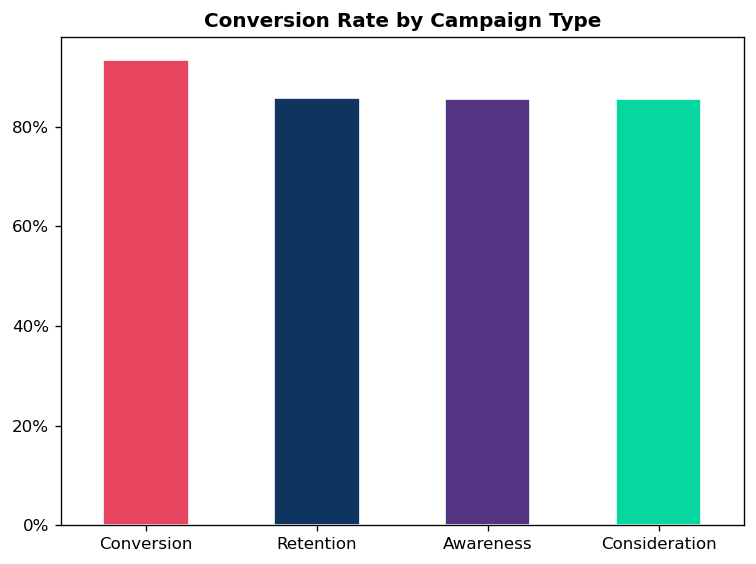

In [76]:
ct_conv = digital_data.groupby('CampaignType')['Conversion'].mean().sort_values(ascending = False)
disp = ct_conv.plot(kind = 'bar', color = PALETTE, edgecolor = 'white', rot = 0)
disp.set_title('Conversion Rate by Campaign Type', fontweight ='bold')
disp.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
disp.set_xlabel('')

plt.tight_layout()
plt.show()

#### Adspend Vs Conversion

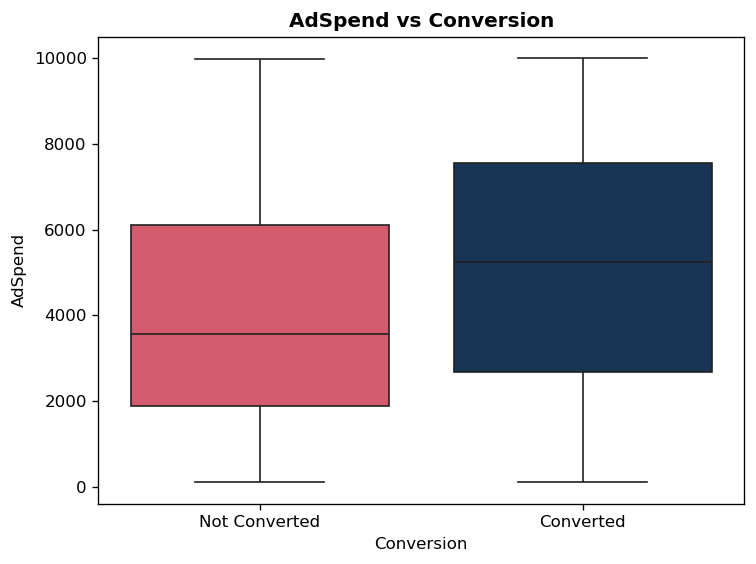

In [87]:
disp = sns.boxplot(x = 'Conversion', y='AdSpend', data = digital_data, palette=['#e94560','#0f3460'])
disp.set_title('AdSpend vs Conversion', fontweight = 'bold')
disp.set_xticklabels(['Not Converted', 'Converted'])

plt.tight_layout()
plt.show()

#### Age Distribution by Conversion

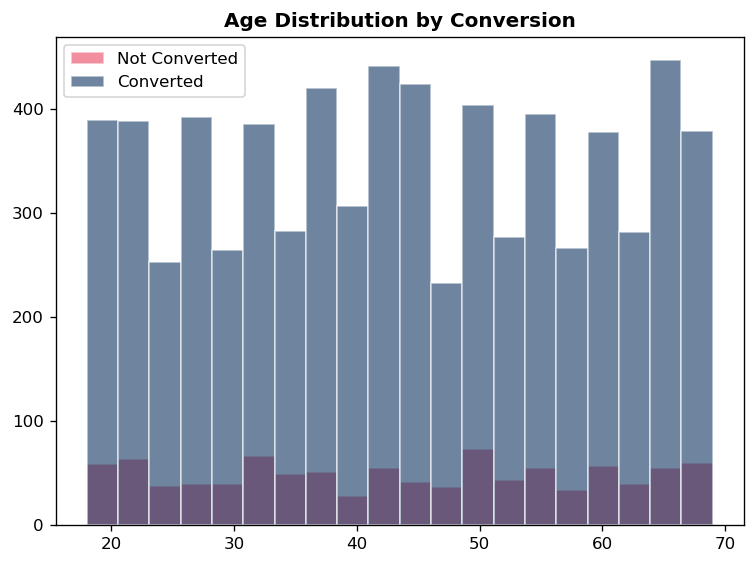

In [94]:
for conv_val, label, color in [(0,'Not Converted', PALETTE[0]),(1, 'Converted', PALETTE[1])]:
    subset = digital_data[digital_data['Conversion'] == conv_val]['Age']
    disp = plt.hist(subset, bins = 20, alpha = 0.6, label = label, color = color, edgecolor = 'white')

plt.title('Age Distribution by Conversion', fontweight = 'bold')
plt.legend()

plt.tight_layout()
plt.show()

#### PreviousPurchases vs Coversion

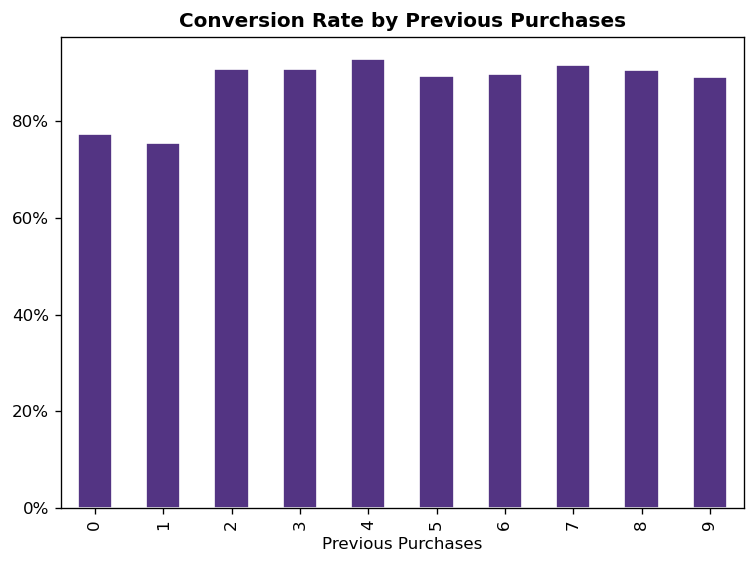

In [109]:
pp_conv = digital_data.groupby('PreviousPurchases')['Conversion'].mean()
disp = pp_conv.plot(kind = 'bar', color = PALETTE[2], edgecolor = 'white')
plt.title('Conversion Rate by Previous Purchases', fontweight = 'bold')
disp.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
disp.set_xlabel('Previous Purchases')

plt.tight_layout()
plt.show()

#### Gender vs Conversion

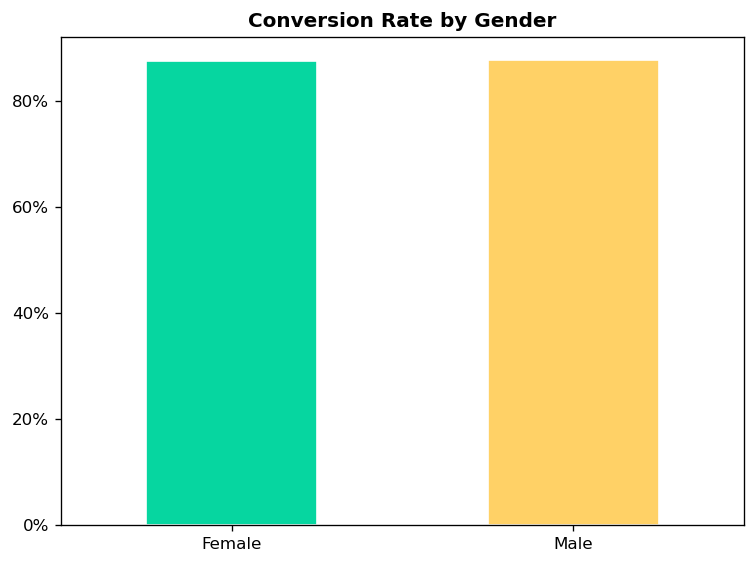

In [118]:
gender_conv = digital_data.groupby('Gender')['Conversion'].mean()
disp = gender_conv.plot(kind = 'bar', color = [PALETTE[3],PALETTE[4]], edgecolor = 'white', rot = 0)
plt.title('Conversion Rate by Gender', fontweight ='bold')
disp.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('')

plt.tight_layout()
plt.show()

<div style="
    background-color:#C0EEF0;
    padding:20px;
    border-radius:12px;
    border:1px solid #ddd;
    margin-bottom:15px;
">
<ul><b>Key Findings:</b>

<li>Campaign Channel: Referral and PPC campaigns show slightly higher conversion rates than other channels.</li>
<li>Campaign Type: Promotional campaigns achieve the highest conversion rate, while Awareness and Consideration perform slightly lower.</li>
<li>Ad Spend: Converted customers generally receive higher advertising spend, indicating a positive relationship between investment and conversion.</li>
<li>Age: Conversions are distributed across all age groups, suggesting age has limited influence on conversion.</li>
<li>Previous Purchases: Customers with prior purchase history are more likely to convert, highlighting the importance of customer retention.</li>
<li>Gender: Conversion rates are nearly identical for male and female customers, indicating gender is not a significant factor.</li>
</ul>
<p>Overall Insight: Customer engagement and purchase history appear to have a greater impact on conversion than demographic characteristics, providing valuable guidance for optimizing marketing strategies.</p>
</div>


#### Correlation Analysis

TimeOnSite           0.129609
EmailClicks          0.129521
EmailOpens           0.124884
AdSpend              0.124672
ClickThroughRate     0.120012
PreviousPurchases    0.111781
PagesPerVisit        0.102840
LoyaltyPoints        0.095004
ConversionRate       0.093185
WebsiteVisits        0.079339
Income               0.013974
SocialShares         0.011449
Age                  0.001606


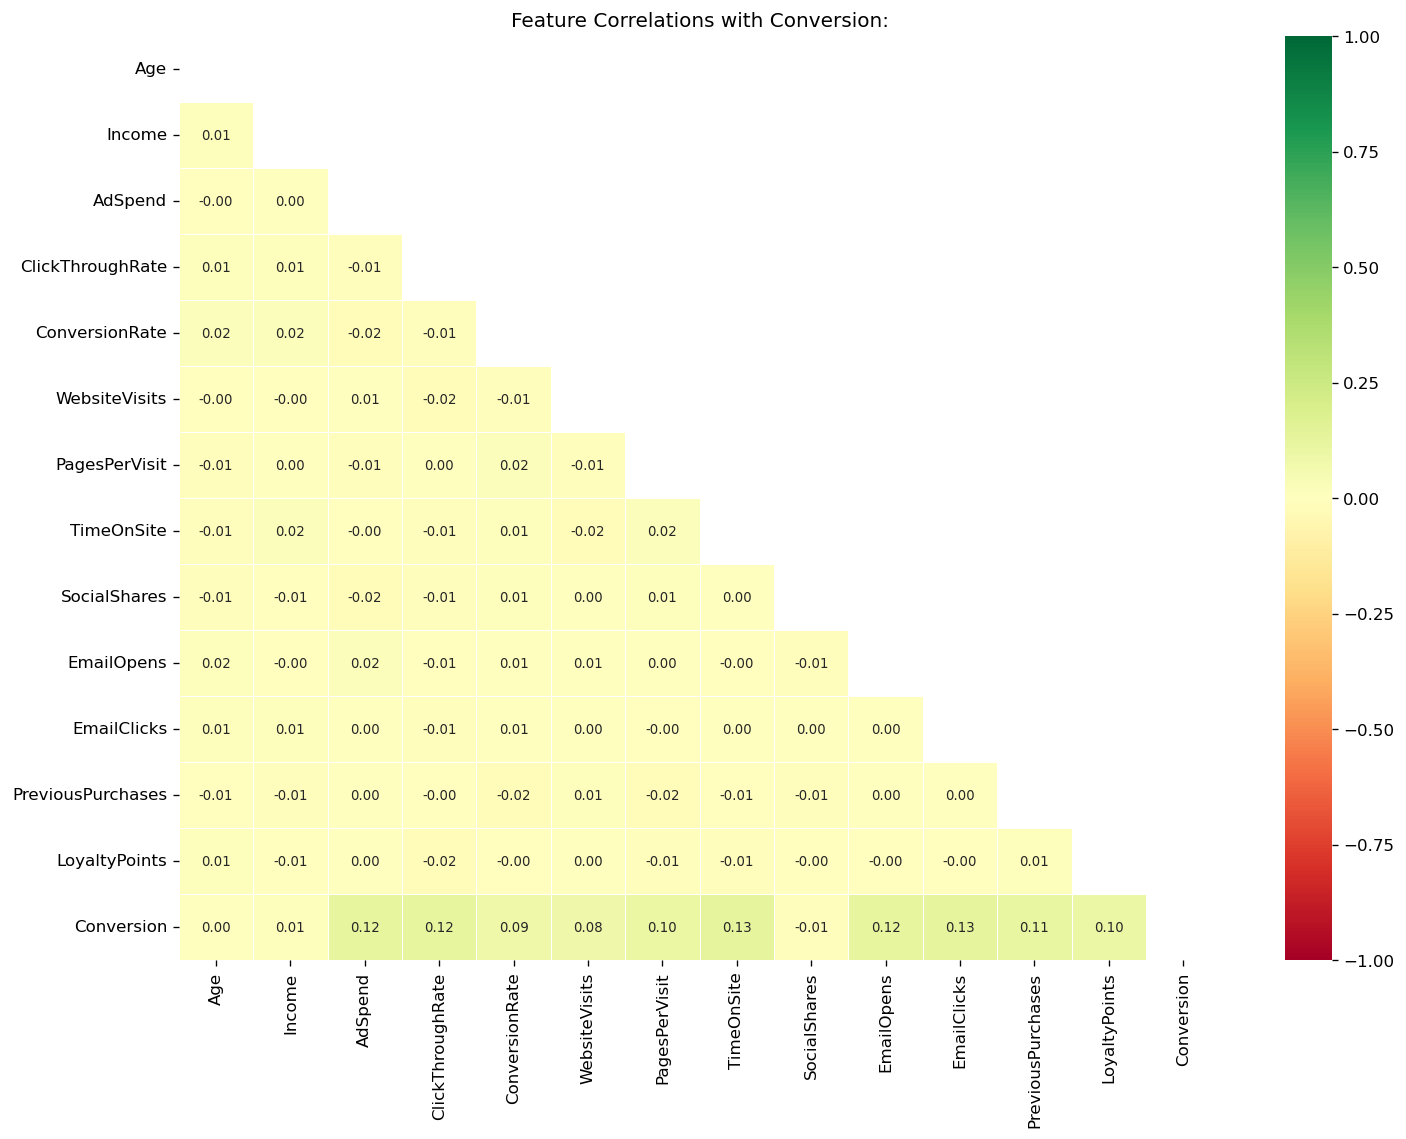

In [132]:
corr_cols = [c for c in num_col] + ['Conversion']
corr_matrix = digital_data[corr_cols].corr()

plt.figure(figsize = (14,10))
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = "RdYlGn",
           mask = mask, linewidth = 0.5, annot_kws = {"size":8},
           vmin=-1,vmax=1,center=0)
plt.title('Feature Correlations with Conversion:')
target_corr = corr_matrix['Conversion'].drop('Conversion').abs().sort_values(ascending=False)
print(target_corr.to_string())

<div style="background-color:#C0EEF0;padding:20px;border-radius:12px;border:1px solid #ddd;margin-bottom:15px;">
<h3><b>📊 EDA Summary & Key Findings</b></h3>
<ul>
<li><b>Class Imbalance:</b> 87.7% converted — standard accuracy is unreliable. Use SMOTE + AUC/F1.</li>
<li><b>Channel Performance:</b> All channels show similar conversion rates (~87%), suggesting channel alone isn't the differentiator.</li>
<li><b>PreviousPurchases & LoyaltyPoints</b> show the strongest positive correlation with Conversion — loyalty drives repeat conversion.</li>
<li><b>AdSpend alone</b> does not strongly predict conversion — efficiency (CTR, ConversionRate) matters more than volume.</li>
<li><b>AdvertisingPlatform & AdvertisingTool</b> have zero variance — will be dropped.</li>
<li><b>CustomerID</b> is an identifier — will be dropped.</li>
</ul>
</div>

#### Feature Engineering

In [6]:
df = digital_data.copy()

# Drop zero-variance & ID columns
df.drop(columns = ['CustomerID', 'AdvertisingPlatform','AdvertisingTool'],inplace= True)
df.head()

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,1


In [8]:
# Email Click Through Rate
df['Email_CTR'] = df['EmailClicks']/(df['EmailClicks']+1) #+1 to avoid division by zero

In [146]:
df['Email_CTR']

0       0.900000
1       0.875000
2       0.666667
3       0.666667
4       0.857143
          ...   
7995    0.857143
7996    0.500000
7997    0.000000
7998    0.833333
7999    0.900000
Name: Email_CTR, Length: 8000, dtype: float64

In [10]:
# Ad Efficiency: composite of website + social behavior
df['AdEfficiency'] = df['ConversionRate'] / (df['AdSpend']+1)

In [150]:
df['AdEfficiency']

0       0.000014
1       0.000047
2       0.000049
3       0.000163
4       0.000065
          ...   
7995    0.000014
7996    0.000133
7997    0.000029
7998    0.000015
7999    0.000007
Name: AdEfficiency, Length: 8000, dtype: float64

In [12]:
# Engagement Score: Conversion per dollar spent
df['EngagementScore'] = (df['WebsiteVisits']*0.3+
                        df['PagesPerVisit']*0.3+
                        df['TimeOnSite']*0.2+
                        df['SocialShares']*0.2)
df['EngagementScore']

0        5.999065
1       15.545651
2        5.826066
3       36.199954
4        4.612728
          ...    
7995    26.653640
7996    28.649924
7997    21.879637
7998    32.976214
7999     9.542154
Name: EngagementScore, Length: 8000, dtype: float64

In [14]:
# Customer Value Score: Loyalty + purchase history
df['CustomerValue'] = df['LoyaltyPoints']+0.6 + df['PreviousPurchases']*100*0.4
df['CustomerValue']

0        848.6
1       3539.6
2       2657.6
3       2463.6
4       4665.6
         ...  
7995     566.6
7996    1702.6
7997     858.6
7998    2989.6
7999     701.6
Name: CustomerValue, Length: 8000, dtype: float64

In [16]:
# Age group Binning
df['AgeGroup'] = pd.cut(df['Age'], bins = [17,30,45,60,70],
                       labels = ['18-30','31-45','46-60','61-70'])
df['AgeGroup'] = df['AgeGroup'].astype(str)
df['AgeGroup']

0       46-60
1       61-70
2       46-60
3       31-45
4       46-60
        ...  
7995    18-30
7996    31-45
7997    18-30
7998    18-30
7999    31-45
Name: AgeGroup, Length: 8000, dtype: str

In [24]:
print(f'New feature count: {df.shape[1]}')
print('New features added:',['Email_CTR','AdEfficiency','EngagementScore','CustomerValue','AgeGroup'])
df.head(3)

New feature count: 22
New features added: ['Email_CTR', 'AdEfficiency', 'EngagementScore', 'CustomerValue', 'AgeGroup']


,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,...,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion,Email_CTR,AdEfficiency,EngagementScore,CustomerValue,AgeGroup
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,...,6,9,4,688,1,0.900000,0.000014,5.999065,848.6,46-60
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,...,2,7,2,3459,1,0.875000,0.000047,15.545651,3539.6,61-70
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,...,11,2,8,2337,1,0.666667,0.000049,5.826066,2657.6,46-60


<div style="background-color:#C0EEF0;padding:20px;border-radius:12px;border:1px solid #ddd;margin-bottom:15px;">
<h3><b>🛠️ Feature Engineering Summary</b></h3>
<ul>
<li><b>Email_CTR:</b> Ratio of email clicks to opens — measures email content effectiveness.</li>
<li><b>AdEfficiency:</b> Conversion rate per unit of ad spend — captures ROI efficiency.</li>
<li><b>EngagementScore:</b> Composite score of website behavior — higher = more engaged user.</li>
<li><b>CustomerValue:</b> Weighted combination of loyalty points and purchase history.</li>
<li><b>AgeGroup:</b> Binned age into meaningful demographic segments.</li>
</ul>
</div>

#### Preprocessing Pipeline

In [18]:
X = df.drop(columns = ['Conversion'])
y = df['Conversion']

#Identify column types
categorical_features = X.select_dtypes(include = 'object').columns.tolist()
numerical_features = X.select_dtypes(include = ['int64', 'float64']).columns.tolist()

print(f'Categorical features ({len(categorical_features)}):{categorical_features}')
print(f'Numerical features ({len(numerical_features)}):{numerical_features}')
print(f'\nTotal features: {X.shape[1]}')

Categorical features (4):['Gender', 'CampaignChannel', 'CampaignType', 'AgeGroup']
Numerical features (17):['Age', 'Income', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'Email_CTR', 'AdEfficiency', 'EngagementScore', 'CustomerValue']

Total features: 21


In [20]:
# Build preproecssing pipeline
numeric_transformer = Pipeline(steps = [
    ('scaler',StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ('onehot', OneHotEncoder(drop = 'first', sparse_output=False, handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size : {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')
print(f'Train class distribution: {dict(y_train.value_counts())}')
print(f'Test class distribution: {dict(y_test.value_counts())}')

Train size : 6,400 | Test size: 1,600
Train class distribution: {1: 5610, 0: 790}
Test class distribution: {1: 1402, 0: 198}


#### Handling Class Imbalance with SMOTE

Before SMOTE: Counter({1: 5610, 0: 790})
After SMOTE: Counter({1: 5610, 0: 5610})


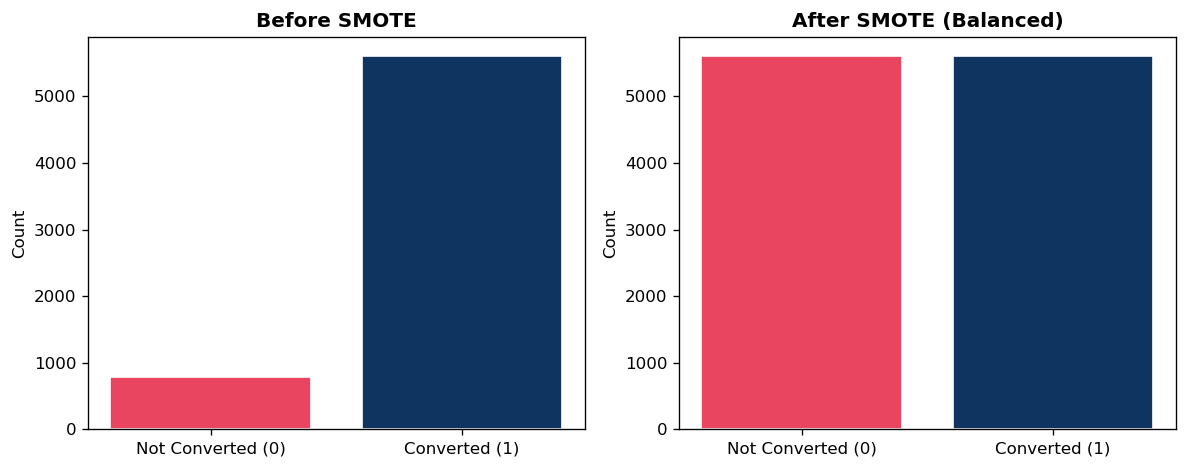

In [22]:
from collections import Counter

# Apply preprocessor first to see numeric shape
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Before SMOTE: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print(f"After SMOTE: {Counter(y_train_res)}")

fig, axes = plt.subplots(1,2, figsize = (10,4))
for ax, counts, title in zip(axes,
                            [Counter(y_train), Counter(y_train_res)],
                            ['Before SMOTE', 'After SMOTE (Balanced)']):
    ax.bar(['Not Converted (0)', 'Converted (1)'],
           [counts[0], counts[1]],color=[PALETTE[0], PALETTE[1]], edgecolor = 'white')
    ax.set_title(title, fontweight = 'bold')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

#### Model Building & Comparison

In [32]:
cv = StratifiedKFold(n_splits=5, shuffle =True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost' : XGBClassifier(n_estimators=200, random_state=42, eval_metric = 'logloss',verbosity = 0)
}

results = {}
print(f'{'Model':<25} {'CV ROC-AUC':>12} {'CV F1':>10} {'CV Accuracy':>13}')
print("-" * 65)

for name, model in models.items():
    auc = cross_val_score(model, X_train_res,y_train_res, cv = cv, scoring = 'roc_auc').mean()
    f1 = cross_val_score(model, X_train_res,y_train_res, cv = cv, scoring = 'f1').mean()
    acc = cross_val_score(model, X_train_res,y_train_res, cv = cv, scoring = 'accuracy').mean()
    results[name] = {'ROC-AUC': auc, 'F1':f1,'Accuracy':acc}
    print(f" {name:<23} {auc:>12.4f} {f1:>10.4f} {acc:>13.4f}")

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending = False)
print("\n Best Model:", results_df['ROC-AUC'].idxmax())


Model                       CV ROC-AUC      CV F1   CV Accuracy
-----------------------------------------------------------------
 Logistic Regression           0.8234     0.7443        0.7465
 Random Forest                 0.9916     0.9675        0.9669
 Gradient Boosting             0.9775     0.9531        0.9514
 XGBoost                          nan     0.9586        0.9578

 Best Model: Random Forest


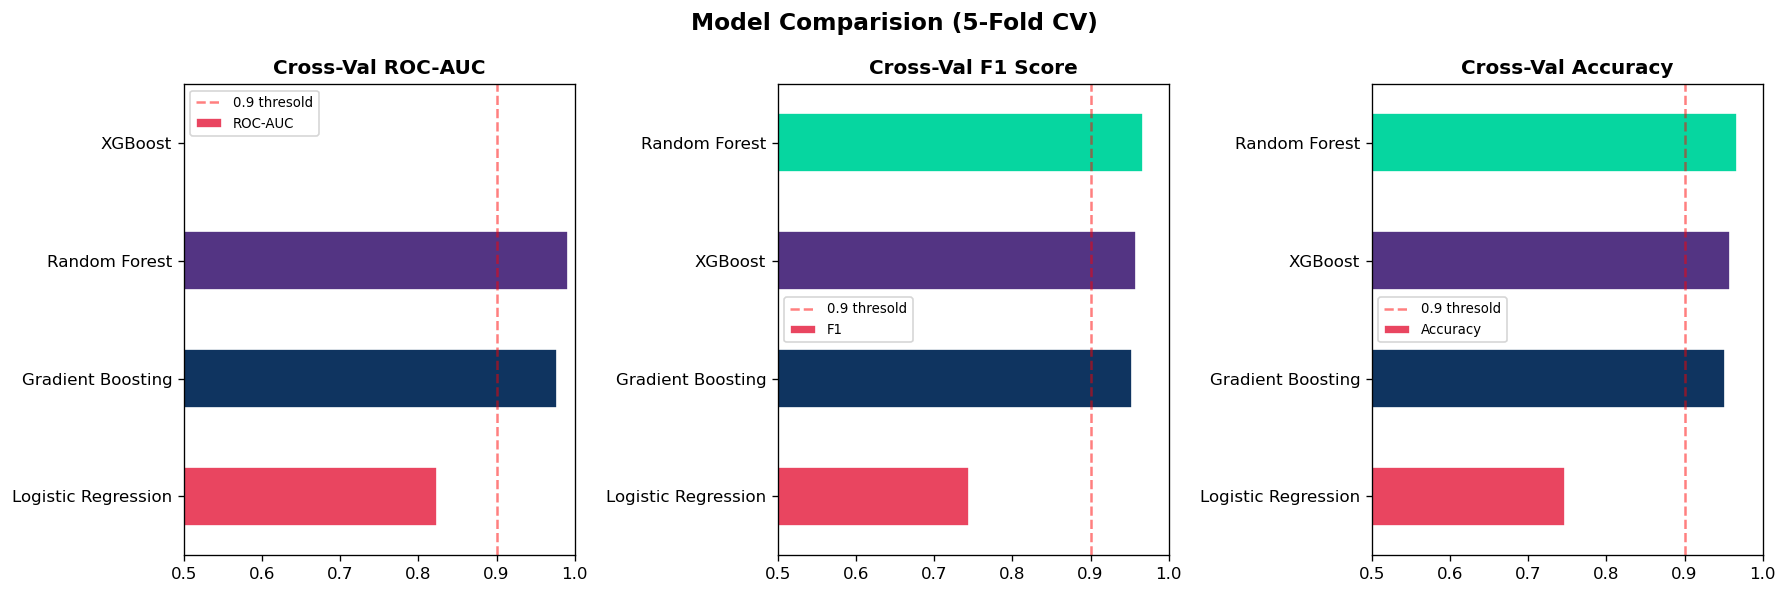

In [34]:
# Visualize model comparision
fig, axes = plt.subplots(1,3, figsize = (15,5))
metrics = ['ROC-AUC', 'F1', 'Accuracy']
titles = ['Cross-Val ROC-AUC', 'Cross-Val F1 Score', 'Cross-Val Accuracy']

for ax,metric,title in zip(axes, metrics, titles):
    results_df[metric].sort_values().plot(kind = 'barh', ax=ax,
                                         color = PALETTE[:len(results_df)], edgecolor = 'white')
    ax.set_title(title, fontweight = 'bold')
    ax.set_xlim(0.5,1.0)
    ax.axvline(0.9, color = 'red', linestyle = '--', alpha = 0.5, label = '0.9 thresold')
    ax.legend(fontsize=8)

plt.suptitle('Model Comparision (5-Fold CV)', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()